In [4]:
import os
import pickle
import tarfile
import datetime
import numpy as np
import urllib.request
import sklearn.metrics
import tensorflow as tf
import matplotlib.pyplot as plt
import zipfile

In [5]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
              tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [6]:
%load_ext tensorboard

In [7]:
BATCH_SIZE = 64
HISTORY_DIR = './history'
os.makedirs(HISTORY_DIR, exist_ok=True)

In [5]:
# def download_data():
#     if not os.path.exists('tiny-imagenet-200'):
#         urllib.request.urlretrieve('http://cs231n.stanford.edu/tiny-imagenet-200.zip', 'tiny-imagenet-200.zip')
#         file = zipfile.ZipFile('tiny-imagenet-200.zip', 'r')
#         file.extractall()

In [8]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
IMG_SIZE = 64
NUM_CLASSES = 200

In [7]:
# уже загружено
# download_data()

In [8]:
# Сделано
# # настроим правильную структуру папок для val
# import os
# import shutil

# val_dir = 'tiny-imagenet-200/val'
# val_images_dir = os.path.join(val_dir, 'images')
# val_annotations_file = os.path.join(val_dir, 'val_annotations.txt')

# # Чтение аннотаций
# with open(val_annotations_file, 'r') as f:
#     for line in f:
#         parts = line.strip().split('\t')
#         img_file = parts[0]
#         class_name = parts[1]
        
#         class_dir = os.path.join(val_dir, class_name)
#         os.makedirs(class_dir, exist_ok=True)
        
#         src_path = os.path.join(val_images_dir, img_file)
#         dst_path = os.path.join(class_dir, img_file)
#         shutil.move(src_path, dst_path)

# # Удалим папку images — она теперь не нужна
# shutil.rmtree(val_images_dir)

In [9]:
train_dataset = image_dataset_from_directory(
    'tiny-imagenet-200/train',
    label_mode='categorical',       # для one-hot меток
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 100001 files belonging to 200 classes.


In [10]:
val_dataset = image_dataset_from_directory(
    'tiny-imagenet-200/val',
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10000 files belonging to 200 classes.


In [8]:
# 1 вариант
# from tensorflow.keras import layers, models, regularizers

# weight_decay = 1e-4  # коэффициент регуляризации

# model = models.Sequential([
#     layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),

#     # Блок 1
#     layers.Conv2D(64, 3, padding='same', use_bias=False,
#                   kernel_regularizer=regularizers.l2(weight_decay)),
#     layers.BatchNormalization(),
#     layers.ReLU(),
#     layers.Conv2D(64, 3, padding='same', use_bias=False,
#                   kernel_regularizer=regularizers.l2(weight_decay)),
#     layers.BatchNormalization(),
#     layers.ReLU(),
#     layers.MaxPooling2D(2),
#     layers.Dropout(0.25),

#     # Блок 2
#     layers.Conv2D(128, 3, padding='same', use_bias=False,
#                   kernel_regularizer=regularizers.l2(weight_decay)),
#     layers.BatchNormalization(),
#     layers.ReLU(),
#     layers.Conv2D(128, 3, padding='same', use_bias=False,
#                   kernel_regularizer=regularizers.l2(weight_decay)),
#     layers.BatchNormalization(),
#     layers.ReLU(),
#     layers.MaxPooling2D(2),
#     layers.Dropout(0.25),

#     # Блок 3
#     layers.Conv2D(256, 3, padding='same', use_bias=False,
#                   kernel_regularizer=regularizers.l2(weight_decay)),
#     layers.BatchNormalization(),
#     layers.ReLU(),
#     layers.Conv2D(256, 3, padding='same', use_bias=False,
#                   kernel_regularizer=regularizers.l2(weight_decay)),
#     layers.BatchNormalization(),
#     layers.ReLU(),
#     layers.MaxPooling2D(2),
#     layers.Dropout(0.25),

#     # Классификатор
#     layers.Flatten(),
#     layers.Dense(512, activation='relu',
#                  kernel_regularizer=regularizers.l2(weight_decay)),
#     layers.Dropout(0.5),
#     layers.Dense(NUM_CLASSES, activation='softmax')
# ])


In [16]:
logdir = os.path.join(HISTORY_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [9]:
# %tensorboard --logdir $logdir
%tensorboard --logdir $logdir

# Вариант 2

# Собрано в одном

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, optimizers
import os

IMG_SIZE = 64
NUM_CLASSES = 200
weight_decay = 1e-4

def build_model():
    model = models.Sequential([
        layers.InputLayer(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Блок 1
        layers.Conv2D(64, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Conv2D(64, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.MaxPooling2D(2),

        # Блок 2
        layers.Conv2D(128, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Conv2D(128, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.MaxPooling2D(2),

        # Блок 3
        layers.Conv2D(384, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Conv2D(384, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Conv2D(384, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.MaxPooling2D(2),

        # Блок 4
        layers.Conv2D(512, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Conv2D(512, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Conv2D(512, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.3),

        # Блок 5
        layers.Conv2D(512, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Conv2D(512, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Conv2D(512, 3, padding='same', use_bias=False,
                      kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Dropout(0.3),

        # Классификатор
        layers.GlobalAveragePooling2D(),
        layers.Dense(2048, use_bias=False, kernel_regularizer=regularizers.l2(weight_decay)),
        layers.BatchNormalization(),
        layers.PReLU(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax',
                     kernel_regularizer=regularizers.l2(weight_decay))
    ])
    return model


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

def augment(ds):
    return ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

train_dataset = augment(train_dataset).prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)


initial_lr = 0.01
decay_rate = 0.95
decay_steps = 1

def exponential_decay(epoch):
    return initial_lr * (decay_rate ** (epoch // decay_steps))

from tensorflow.keras.callbacks import LearningRateScheduler

logdir = os.path.join(HISTORY_DIR, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(logdir, 'model_tiny.keras'),
        save_best_only=True
    ),
    tf.keras.callbacks.TensorBoard(os.path.join(logdir, 'logs')),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    ),
    LearningRateScheduler(exponential_decay, verbose=1)
]

model = build_model()

# Loss с label smoothing
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=optimizers.SGD(learning_rate=initial_lr, momentum=0.9, nesterov=True),
    loss=loss_fn,
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callbacks
)


Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2635s 2s/step - accuracy: 0.0107 - loss: 6.4167 - val_accuracy: 0.0283 - val_loss: 5.9656 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.0095.
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2627s 2s/step - accuracy: 0.0309 - loss: 5.6560 - val_accuracy: 0.0551 - val_loss: 5.3571 - learning_rate: 0.0095

Epoch 3: LearningRateScheduler setting learning rate to 0.009025.
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2636s 2s/step - accuracy: 0.0549 - loss: 5.3073 - val_accuracy: 0.0729 - val_loss: 5.1835 - learning_rate: 0.0090

Epoch 4: LearningRateScheduler setting learning rate to 0.00857375.
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2634s 2s/step - accuracy: 0.0854 - loss: 5.0855 - val_accuracy: 0.0911 - val_loss: 5.0456 - learning_rate: 0.0086

Epoch 5: LearningRateScheduler setting learning rate to 0.0081450625.
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━

In [11]:
from tensorflow.keras.models import load_model

model_path = r'C:\Users\maxim\NN\tiny_imagenet\history\20250531-002639\model_tiny.keras'
model = load_model(model_path, compile=True)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 64, 64, 64)          │           1,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_14 (PReLU)                   │ (None, 64, 64, 64)          │         262,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 64, 64, 64)          │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_15 (PReLU)                   │ (None, 64, 64, 64)          │         262,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 32, 32, 128)         │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_16 (PReLU)                   │ (None, 32, 32, 128)         │         131,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 32, 32, 128)         │         147,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_17 (PReLU)                   │ (None, 32, 32, 128)         │         131,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 16, 16, 384)         │         442,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 16, 16, 384)         │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_18 (PReLU)                   │ (None, 16, 16, 384)         │          98,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 16, 16, 384)         │       1,327,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 16, 16, 384)         │           1,5

 Total params: 39,213,842 (149.59 MB)

 Trainable params: 19,600,264 (74.77 MB)

 Non-trainable params: 13,312 (52.00 KB)

 Optimizer params: 19,600,266 (74.77 MB)

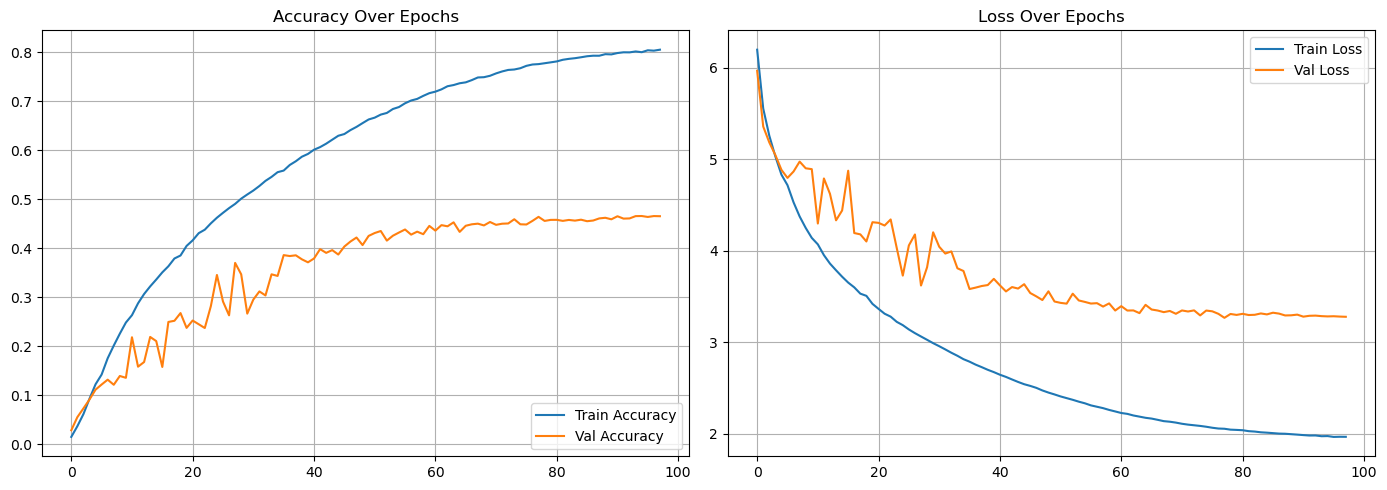

In [12]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy Over Epochs')
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Loss Over Epochs')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [12]:
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation loss: {val_loss:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 504ms/step - accuracy: 0.4793 - loss: 3.2071 
Validation accuracy: 0.4639
Validation loss: 3.2679


In [23]:
y_true = []
for _, labels in val_dataset.unbatch():
    y_true.append(np.argmax(labels.numpy()))
y_true = np.array(y_true)


y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 386ms/step 


In [24]:
_, ax = plt.subplots(figsize=(75, 75))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)
plt.tight_layout()
plt.savefig('valid.png')

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Классификационный отчёт:\n")
print(classification_report(y_true, y_pred, zero_division=0))

Классификационный отчёт:

              precision    recall  f1-score   support

           0       0.73      0.70      0.71        50
           1       0.85      0.68      0.76        50
           2       0.54      0.42      0.47        50
           3       0.35      0.22      0.27        50
           4       0.37      0.42      0.39        50
           5       0.38      0.22      0.28        50
           6       0.35      0.58      0.44        50
           7       0.44      0.38      0.41        50
           8       0.76      0.68      0.72        50
           9       0.62      0.42      0.50        50
          10       0.39      0.54      0.45        50
          11       0.52      0.48      0.50        50
          12       0.33      0.78      0.46        50
          13       0.65      0.78      0.71        50
          14       0.35      0.68      0.47        50
          15       0.56      0.50      0.53        50
          16       0.39      0.26      0.31        50
 

In [20]:
acc = accuracy_score(y_true, y_pred)
print(f"\n Accuracy на валидации: {acc:.4f}")


 Accuracy на валидации: 0.4639


In [1]:
from tensorflow.keras.models import load_model

model_path = r'C:\Users\maxim\NN\tiny_imagenet\history\20250531-002639\model_tiny.keras'
model = load_model(model_path, compile=True)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 64, 64, 64)          │           1,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_14 (PReLU)                   │ (None, 64, 64, 64)          │         262,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 64, 64, 64)          │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_15 (PReLU)                   │ (None, 64, 64, 64)          │         262,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 32, 32, 128)         │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_16 (PReLU)                   │ (None, 32, 32, 128)         │         131,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 32, 32, 128)         │         147,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_17 (PReLU)                   │ (None, 32, 32, 128)         │         131,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 16, 16, 384)         │         442,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 16, 16, 384)         │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_18 (PReLU)                   │ (None, 16, 16, 384)         │          98,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 16, 16, 384)         │       1,327,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 16, 16, 384)         │           1,5

 Total params: 39,213,842 (149.59 MB)

 Trainable params: 19,600,264 (74.77 MB)

 Non-trainable params: 13,312 (52.00 KB)

 Optimizer params: 19,600,266 (74.77 MB)

In [13]:
initial_lr = 0.00001
decay_rate = 0.95
decay_steps = 1

def exponential_decay(epoch):
    return initial_lr * (decay_rate ** (epoch // decay_steps))

In [18]:
from tensorflow.keras.callbacks import LearningRateScheduler
import os

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(logdir, 'model_tiny_2.keras'),
        save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    LearningRateScheduler(exponential_decay, verbose=1)
]

In [19]:
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset,
    callbacks=callbacks
)


Epoch 1: LearningRateScheduler setting learning rate to 1e-05.
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2263s 1s/step - accuracy: 0.8297 - loss: 1.1031 - val_accuracy: 0.5440 - val_loss: 2.3020 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.5e-06.
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2249s 1s/step - accuracy: 0.8459 - loss: 1.0297 - val_accuracy: 0.5461 - val_loss: 2.2803 - learning_rate: 9.5000e-06

Epoch 3: LearningRateScheduler setting learning rate to 9.025e-06.
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2254s 1s/step - accuracy: 0.8525 - loss: 1.0042 - val_accuracy: 0.5480 - val_loss: 2.2701 - learning_rate: 9.0250e-06

Epoch 4: LearningRateScheduler setting learning rate to 8.573749999999999e-06.
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2238s 1s/step - accuracy: 0.8547 - loss: 0.9943 - val_accuracy: 0.5494 - val_loss: 2.2618 - learning_rate: 8.5738e-06

Epoch 5: LearningRateScheduler setting learning rate to 8.1450625e-06.
Epoch 5/5
1563

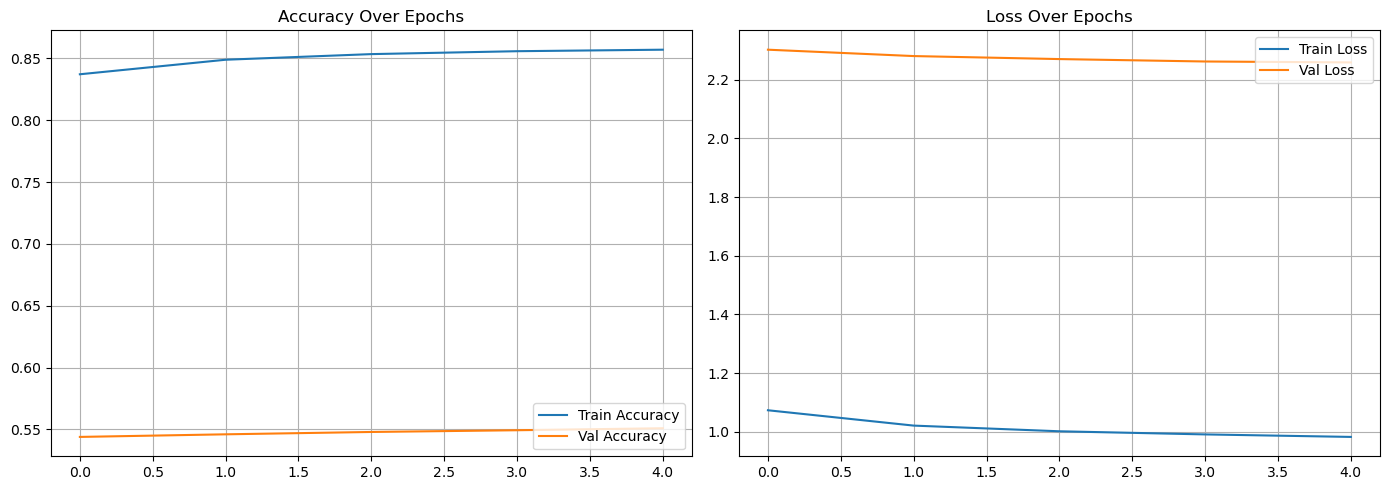

In [20]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Accuracy Over Epochs')
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Loss Over Epochs')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [21]:
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation loss: {val_loss:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 390ms/step - accuracy: 0.5839 - loss: 2.1146
Validation accuracy: 0.5510
Validation loss: 2.2587
